In [1]:
import os, sys
import pandas as pd

sys.path.append("../")
from pymoods.utils.mocodo import *

In [2]:
DATA_DIR = "../../data"
JLD2_FILEDIR = os.path.join(DATA_DIR, "DataExchangeMilan_Project2.2a/solution")
OUTPUT_DIR = os.path.join(DATA_DIR, "DataExchangeMilan_Project2.2a/processed")

In [3]:
# df_design = pd.read_csv(f"{JLD2_FILEDIR}/Design_sol.csv")
# df_design["config"] = df_design["Scenario"].str.replace("-", "_") + "_" + df_design["Wind Farm"].str.lower()
# sel_columns = [c for c in df_design.columns if c not in ["Scenario", "Wind Farm"]]
# df_design = df_design[sel_columns].set_index("config").ffill()
# df_design.index = df_design.index.str.replace(" ", "")
# df_design

In [4]:
df_scenario = pd.read_csv(f"{OUTPUT_DIR}/scenarios.csv", index_col=["config", "sim", "time"])
df_scenario

ChS      DisS        SCS     WPQ        WSQ  \
config           sim time                                                     
Base_cotwdpge    22  0     0.005304  0.002016  72.400653     0.0   1.631244   
                     1     0.006830  0.001833  72.401701     0.0   1.631244   
                     2     0.009288  0.001677  72.403353     0.0   1.631244   
                     3     0.013716  0.001543  72.406050     0.0   1.631244   
                     4     0.024299  0.001415  72.411189     0.0   1.656754   
...                             ...       ...        ...     ...        ...   
CCD22_8_wcascade 121 91    0.000059  0.000026   0.000942  1500.0  17.991168   
                     92    0.000075  0.000023   0.000953  1500.0  17.374414   
                     93    0.000070  0.000024   0.000963  1500.0  17.374414   
                     94    0.000066  0.000024   0.000971  1500.0  17.374414   
                     95    0.000063  0.000025   0.000978  1500.0  17.374414   

                                kBS       kWS        lam_DAQ         lam_RT  \
config           sim time                                                     
Base_cotwdpge    22  0     2.000000  0.000000  111068.493725  113957.371061   
                     1     2.000000  0.000000  111068.493725  111151.766882   
                     2     2.000000  0.000000  111068.493725  108346.162703   
                     3     2.000000  0.000000  111068.493725  105540.558524   
                     4     2.000000  0.000000  100218.649657  102734.954344   
...                             ...       ...            ...            ...   
CCD22_8_wcascade 121 91    3.000008  2.000002  109309.411495  109322.831882   
                     92    3.000008  2.000002  106736.493470  107895.749806   
                     93    3.000008  2.000002  106736.493470  109038.031966   
                     94    3.000008  2.000002  106736.493470  110180.314127   
                     95    3.000008  2.000002  106736.493470  111322.596288   

                              pRBDS  ...     pRWDS     pRWUS        pWDSQ  \
config           sim time            ...                                    
Base_cotwdpge    22  0     1.508333  ...  0.000000   0.00000   750.441807   
                     1     1.508333  ...  0.000000   0.00000   750.441807   
                     2     1.508333  ...  0.000000   0.00000   750.441807   
                     3     1.508333  ...  0.000000   0.00000   750.441807   
                     4     1.508333  ...  0.000000   0.00000   716.536060   
...                             ...  ...       ...       ...          ...   
CCD22_8_wcascade 121 91    1.875005  ...  1.250001  12.21711  1219.865148   
                     92    1.875005  ...  1.250001  12.21711  1210.194031   
                     93    1.875005  ...  1.250001  12.21711  1210.194031   
                     94    1.875005  ...  1.250001  12.21711  1210.194031   
                     95    1.875005  ...  1.250001  12.21711  1210.194031   

                                 pWRS         pWSQ          v1          v2  \
config           sim time                                                    
Base_cotwdpge    22  0    -750.445317     0.000000  475.731414  475.731415   
                     1    -750.447030     0.000000  475.729736  475.729736   
                     2    -750.449650     0.000000  475.728057  475.728058   
                     3    -750.454218     0.000000  475.726378  475.726379   
                     4    -716.559184     0.000000  475.723523  475.723523   
...                               ...          ...         ...         ...   
CCD22_8_wcascade 121 91    234.262944  1487.537355  509.999880  498.553512   
                     92    243.934047  1487.512235  509.999875  498.553507   
                     93    243.934053  1487.512235  509.999876  498.553508   
                     94    243.934057  1487.512235  509.999877  498.553509   
                     95    243.934062 

In [5]:
def compute_objectives(CS, SZ, cable_length, scaler_dict, kerntree, df_realigned):
    # default values
    CabLength = cable_length
    PowerBase = scaler_dict['PowerBase']
    
    CabC = 2*0.3476*0.3351*1e6/525/1e3*CabLength # Cable material cost $/MW # Cable material cost $/p.u
    lam_ESS = 1.27009e6 # BESS cost $/MW, 4h duration
    
    CabFixC = 2*0.3476*0.0001*CabLength # Cable fixed cost
    CabIntC = 2.7*1e6/16000*CabLength; # Cable installation cost

    # other fixed cost
    OnConv = 450*1e6 # onshore converter
    OffConv = 772*1e6; # floating offshore converter
    
    TaxCredit = 0.3 # 30% tax credit for capital cost

    S1 = scaler_dict["S1"]
    S2 = scaler_dict["S2"] # scenario picker
    S21 = scaler_dict["S21"]

    # probability sets
    P1 = dict()
    P2 = dict()
    P21 = dict()
    for s in S1:
        P1[s] = kerntree["probability"][s-1]
    
    for s in S2:
        P2[s] = kerntree["probability"][s-1]*kerntree["probability"][kerntree["parent"][s-1]-1]
        P21[s] = kerntree["probability"][s]

    lam_DA = dict()
    lam_RT = dict()
    lam_ReU = dict()
    lam_ReD = dict()
    WS = dict()
    WP = dict()
    
    for s in S1:
        lam_DA[s] = kerntree["state"][s-1, :] # DA price scenarios
    
    for s in S2:
        WS[s] = kerntree["state"][s-1, :]
        # WP[s] = Turbine_PC.(WS[s], (breakpts,), (coefs,))/RatedPower*SW
        col = kerntree["children"][s][0]
        lam_RT[s] = States[col-1, :] # RT price scenarios
        col = kerntree["children"][col][0]
        lam_ReU[s] = States[col-1, :] # Up reserve price scenarios
        col = kerntree["children"][col][0]
        lam_ReD[s] = States[col-1, :] # Down reserve price scenarios

    # objective values
    cable_cost = (1-TaxCredit)*CabC*CS
    ess_cost = (1-TaxCredit)*lam_ESS*SZ

    complete_dict = {}
    dar_dict = {}
    dar = 0
    for dt_scenario in S1:
        dar_series = (lam_DA[dt_scenario] * df_realigned.loc[kerntree["children"][dt_scenario][0]]["pWDSQ"][::4] * P1[dt_scenario]) / 1e3
        dar += dar_series.sum()
        for rt_scenario in kerntree["children"][dt_scenario]:
            dar_dict[rt_scenario] = dar_series.to_dict()
    complete_dict["DAR"] = dar_dict
    
    rtr_dict = {}
    rtr = 0
    for rt_scenario in S2:
        rtr_series = (lam_RT[rt_scenario] * df_realigned.loc[rt_scenario]["pWRS"] * P2[rt_scenario]) / 4 / 1e3
        rtr += rtr_series.sum()
        rtr_dict[rt_scenario] = rtr_series.to_dict()
    complete_dict["RTR"] = rtr_dict
    
    rewr_dict = {}
    rewr = 0
    for rt_scenario in S2:
        rewr_series = ((lam_ReU[rt_scenario] * df_realigned.loc[rt_scenario]["pRWUS"]) + 
                                 (lam_ReD[rt_scenario] * df_realigned.loc[rt_scenario]["pRWDS"])) * P2[rt_scenario] / 4 / 1e3
        rewr += rewr_series.sum()
        rewr_dict[rt_scenario] = rewr_series.to_dict()
    complete_dict["REWR"] = rewr_dict

    rebr_dict = {}
    rebr = 0
    for rt_scenario in S2:
        rebr_series = ((lam_ReU[rt_scenario] * df_realigned.loc[rt_scenario]["pRBUS"]) + 
                                 (lam_ReD[rt_scenario] * df_realigned.loc[rt_scenario]["pRBDS"])) * P2[rt_scenario] / 4 / 1e3
        rebr += rebr_series.sum()
        rebr_dict[rt_scenario] = rebr_series.to_dict()
    complete_dict["REBR"] = rebr_dict

    return {
        "Cable Capacity(MW)": CS,
        "Battery Rated Power(MW)": SZ,
        "Cable Material Cost($M)": cable_cost / 1e6,
        "Battery Cost($M)": ess_cost / 1e6,
        "Day-Ahead Revenue ($k)": dar,
        "Real-Time Revenue ($k)": rtr,
        "Reserve WF Revenue ($k)": rewr,        
        "Reserve ESS Revenue ($k)": rebr
    }, complete_dict

In [6]:
cable_lengths = dict({
    "WCASCADE": 545.060*1e3, 
    "JohnDay": 444.423*1e3, 
    "COTWDPGE": 324.193*1e3, 
    "Tesla": 603.598*1e3, 
    "Mossland": 660.732*1e3
})

In [7]:
usecases = ["Base", "No ESS", "No Reserve", "CCD18-3", "CCD18-5", "CCD18-8", "CCD22-3", "CCD22-5", "CCD22-8"]
locations = ["COTWDPGE", "JohnDay", "Mossland", "Tesla", "WCASCADE"]
results = {}
combined_dict = {}
for case in usecases:
    for loc in locations:
        # print(case, loc)
        data_file = f"{JLD2_FILEDIR}/{case}/{loc}_Sol.jld2"
        df_realigned, scaler_dict = read_jld2_solution_file_as_df(data_file)
        scaler_dict["CL"] = cable_lengths[loc]
        
        if case in ["Base", "No ESS", "No Reserve", "CCD18-3", "CCD18-5", "CCD18-8"]:
            kerntree_file = f'{JLD2_FILEDIR}/ScenarioTree18/ScenTree_{loc}.jld2'
        else:
            kerntree_file = f'{JLD2_FILEDIR}/ScenarioTree22/ScenTree_{loc}.jld2'
        
        kerntree = read_kerntree(kerntree_file)
        States = interpolate_states(kerntree["state"])

        # solution
        tag = f"{case.replace("-", "_")}_{loc.lower()}"
        # design_solutions = df_design.loc[tag]
        CS = scaler_dict["CSS"]
        SZ = scaler_dict["SZS"]
        cable_length = scaler_dict["CL"]
        results[tag], combined_dict[tag] = compute_objectives(CS, SZ, cable_length, scaler_dict, kerntree, df_realigned)

In [8]:
# case = "CCD18-3"
# loc = "COTWDPGE"

# data_file = f"{JLD2_FILEDIR}/{case}/{loc}_Sol.jld2"
# df_realigned, scaler_dict = read_jld2_solution_file_as_df(data_file)

# kerntree_file = f'{JLD2_FILEDIR}/{case}/ScenTree_{loc}.jld2'
# kerntree = read_kerntree(kerntree_file)

# States = interpolate_states(kerntree["state"])

# # solution
# design_solutions = df_design.loc[f"{case.replace("-", "_")}_{loc.lower()}"]
# CS = design_solutions["Cable Capacity(MW)"]
# SZ = design_solutions["Battery Rated Power(MW)"]
# compute_objectives(CS, SZ, scaler_dict, kerntree, df_realigned)

In [9]:
design_solution = pd.DataFrame(results).T
design_solution.to_csv(f"{OUTPUT_DIR}/design_solutions.csv")
design_solution

,Cable Capacity(MW),Battery Rated Power(MW),Cable Material Cost($M),Battery Cost($M),Day-Ahead Revenue ($k),Real-Time Revenue ($k),Reserve WF Revenue ($k),Reserve ESS Revenue ($k)
Base_cotwdpge,2600.000000,36.200000,261.818246,32.184081,1040.759934,29.040111,2.529768,0.738513
Base_johnday,2600.000000,47.000000,358.915986,41.785961,1303.210991,45.328622,3.192498,0.959951
Base_mossland,2600.000000,36.000000,533.607121,32.006268,919.337641,28.506600,2.244915,0.733595
Base_tesla,5200.000000,52.800000,974.931412,46.942526,1422.478138,49.483370,3.473485,1.084099
Base_wcascade,2600.000000,30.000000,440.190421,26.671890,876.802486,25.572794,2.081571,0.605057
No ESS_cotwdpge,1991.001203,0.000000,200.492478,0.000000,1068.932503,19.655535,1.278009,0.000000
No ESS_johnday,2585.000202,0.000000,356.845345,0.000000,1338.568265,32.860630,1.618871,0.000000
No ESS_mossland,1980.000054,0.000000,406.362357,0.000000,944.294322,19.417396,1.144392,0.000000
No ESS_tesla,2904.000009,0.000000,544.461698,0.000000,1459.967335,36.666428,1.762601,0.000000
No ESS_wcascade,1650.001811,0.000000,279.351920,0.000000,899.138883,19.083300,1.050217,0.000000


In [10]:
scenario_frames = []
for case in usecases:
    for loc in locations:
        out_dict = {}
        usecase = f"{case.replace("-", "_")}_{loc.lower()}"
        for k, value in combined_dict[usecase].items():
            sum_series = pd.DataFrame(value).sum(axis=0)
            if k == "DAR":
                # DAR is created for each children though the revenue will only happen once. 
                # If summing up, it should be divided by 5
                sum_series = sum_series 
            out_dict[k] = sum_series.to_dict()
            
        scenario_revenue = pd.DataFrame(out_dict)
        scenario_revenue["config"] = usecase
        scenario_revenue.index.name = "sim"
        scenario_frames.append(scenario_revenue)

In [11]:
rename_columns = {
    "DAR": "Day-Ahead Revenue ($k)",
    "RTR": "Real-Time Revenue ($k)",
    "REWR": "Reserve WF Revenue ($k)",
    "REBR": "Reserve ESS Revenue ($k)"
}
expanded_col_names = [
    "Day-Ahead Revenue ($k)", "Real-Time Revenue ($k)", "Reserve WF Revenue ($k)", "Reserve ESS Revenue ($k)"
]

df_design_solution = pd.concat(scenario_frames).reset_index().set_index(["config", "sim"])
df_design_solution = df_design_solution.rename(columns=rename_columns)
df_design_solution = pd.merge(
    design_solution[[
        "Cable Capacity(MW)", "Battery Rated Power(MW)", "Cable Material Cost($M)", "Battery Cost($M)"
    ]],
    df_design_solution, 
    left_index=True,
    right_on="config"
)

# save to csv
df_design_solution.to_csv(f"{OUTPUT_DIR}/design_solutions_per_scenario.csv")
df_design_solution

Cable Capacity(MW)  Battery Rated Power(MW)  \
config           sim                                                
Base_cotwdpge    22          2600.000000                36.200000   
                 23          2600.000000                36.200000   
                 24          2600.000000                36.200000   
                 25          2600.000000                36.200000   
                 26          2600.000000                36.200000   
...                                  ...                      ...   
CCD22_8_wcascade 117         1650.015151                45.000245   
                 118         1650.015151                45.000245   
                 119         1650.015151                45.000245   
                 120         1650.015151                45.000245   
                 121         1650.015151                45.000245   

                      Cable Material Cost($M)  Battery Cost($M)  \
config           sim                                              
Base_cotwdpge    22                261.818246         32.184081   
                 23                261.818246         32.184081   
                 24                261.818246         32.184081   
                 25                261.818246         32.184081   
                 26                261.818246         32.184081   
...                                       ...               ...   
CCD22_8_wcascade 117               279.354179         40.008053   
                 118               279.354179         40.008053   
                 119               279.354179         40.008053   
                 120               279.354179         40.008053   
                 121               279.354179         40.008053   

                      Day-Ahead Revenue ($k)  Real-Time Revenue ($k)  \
config           sim                                                   
Base_cotwdpge    22                53.342842              -11.589288   
                 23                53.342842               -3.006324   
                 24                53.342842               -5.214967   
                 25                53.342842                2.644101   
                 26                53.342842               17.872314   
...                                      ...                     ...   
CCD22_8_wcascade 117              111.214781              -21.220892   
                 118              111.214781                7.534443   
                 119              111.214781                4.529434   
                 120              111.214781                7.551567   
                 121              111.214781                2.767467   

                      Reserve WF Revenue ($k)  Reserve ESS Revenue ($k)  
config           sim                                                     
Base_cotwdpge    22                  0.004268                  0.004710  
                 23                  0.000850                  0.002057  
                 24                  0.001355                  0.001465  
                 25                  0.000654                  0.000158  
                 26                  0.023466                  0.004765  
...                                       ...                       ...  
CCD22_8_wcascade 117                 0.004141                  0.020805  
                 118                 0.006092                  0.009290  
                 119                 0.001894                  0.002898  
                 120                 0.011331                  0.019789  
                 121                 0.000833                  0.001274  

[4500 rows x 8 columns]

In [12]:
# s1_frame = pd.json_normalize(s1_dict, sep='.').T
# s1_frame.index = pd.MultiIndex.from_tuples([tuple(k.split('.')) for k in s1_frame.index])
# s1_frame.columns = ['DAR']
# s1_frame.index.names = ['config', 'sim', 'time']
# s1_frame

In [13]:
s2_frame = pd.json_normalize(combined_dict, sep='.').T
s2_frame.index = pd.MultiIndex.from_tuples([tuple(k.split('.')) for k in s2_frame.index])
s2_frame = s2_frame.unstack(level=1)
s2_frame.columns = s2_frame.columns.droplevel(0)
s2_frame.index = s2_frame.index.set_levels(
    [s2_frame.index.levels[0], s2_frame.index.levels[1].astype(int), s2_frame.index.levels[2].astype(int)]
)
s2_frame.sort_index(inplace=True)
s2_frame.index.names = ['config', 'sim', 'time']
s2_frame = s2_frame.rename(columns=rename_columns)
s2_frame

Day-Ahead Revenue ($k)  \
config              sim time                           
Base_cotwdpge       22  0                   1.825421   
                        1                        NaN   
                        2                        NaN   
                        3                        NaN   
                        4                   1.572685   
...                                              ...   
No Reserve_wcascade 121 91                       NaN   
                        92                  1.752213   
                        93                       NaN   
                        94                       NaN   
                        95                       NaN   

                              Reserve ESS Revenue ($k)  \
config              sim time                             
Base_cotwdpge       22  0                     0.000028   
                        1                     0.000028   
                        2                     0.000029   
                        3                     0.000029   
                        4                     0.000030   
...                                                ...   
No Reserve_wcascade 121 91                    0.000000   
                        92                    0.000000   
                        93                    0.000000   
                        94                    0.000000   
                        95                    0.000000   

                              Reserve WF Revenue ($k)  Real-Time Revenue ($k)  
config              sim time                                                   
Base_cotwdpge       22  0                         0.0               -0.169856  
                        1                         0.0               -0.165675  
                        2                         0.0               -0.161494  
                        3                         0.0               -0.157313  
                        4                         0.0               -0.146215  
...                                               ...                     ...  
No Reserve_wcascade 121 91                        0.0                0.004885  
                        92                        0.0                0.004980  
                        93                        0.0                0.005036  
                        94                        0.0                0.005092  
                        95                        0.0                0.005148  

[432000 rows x 4 columns]

In [14]:
df_complete = pd.merge(df_scenario, s2_frame, left_index=True, right_index=True)
df_complete.to_csv(f"{OUTPUT_DIR}/scenarios_wrevenues.csv")

df_subset = pd.merge(
    df_scenario[["WSQ", "lam_DAQ", "lam_RT", "pWDSQ", "pWRS", "pWSQ", "DisS"]], 
    s2_frame, left_index=True, right_index=True
)
df_complete.to_csv(f"{OUTPUT_DIR}/scenarios_wrevenues_subset.csv")

In [15]:
df_complete.reset_index()["config"].unique()

array(['Base_cotwdpge', 'Base_johnday', 'Base_mossland', 'Base_tesla',
       'Base_wcascade', 'No ESS_cotwdpge', 'No ESS_johnday',
       'No ESS_mossland', 'No ESS_tesla', 'No ESS_wcascade',
       'No Reserve_cotwdpge', 'No Reserve_johnday', 'No Reserve_mossland',
       'No Reserve_tesla', 'No Reserve_wcascade', 'CCD18_3_cotwdpge',
       'CCD18_3_johnday', 'CCD18_3_mossland', 'CCD18_3_tesla',
       'CCD18_3_wcascade', 'CCD18_5_cotwdpge', 'CCD18_5_johnday',
       'CCD18_5_mossland', 'CCD18_5_tesla', 'CCD18_5_wcascade',
       'CCD18_8_cotwdpge', 'CCD18_8_johnday', 'CCD18_8_mossland',
       'CCD18_8_tesla', 'CCD18_8_wcascade', 'CCD22_3_cotwdpge',
       'CCD22_3_johnday', 'CCD22_3_mossland', 'CCD22_3_tesla',
       'CCD22_3_wcascade', 'CCD22_5_cotwdpge', 'CCD22_5_johnday',
       'CCD22_5_mossland', 'CCD22_5_tesla', 'CCD22_5_wcascade',
       'CCD22_8_cotwdpge', 'CCD22_8_johnday', 'CCD22_8_mossland',
       'CCD22_8_tesla', 'CCD22_8_wcascade'], dtype=object)

(array([ 5., 11., 11., 15., 16., 20.,  9.,  7.,  4.,  2.]),
 array([0.04119464, 0.07720738, 0.11322012, 0.14923285, 0.18524559,
        0.22125832, 0.25727106, 0.29328379, 0.32929653, 0.36530927,
        0.401322  ]),
 <BarContainer object of 10 artists>)

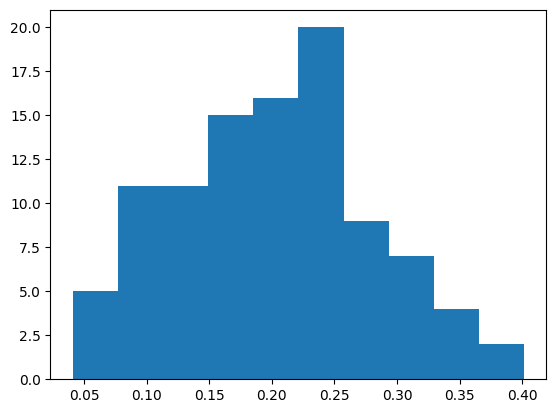

In [16]:
import matplotlib.pyplot as plt
plt.hist(kerntree["probability"][21:121])

In [17]:
kerntree["parent"][21]

np.int64(2)